In [5]:
# Environment bootstrap: install missing packages if needed
import sys, subprocess, importlib

def ensure_pkg(import_name, pip_name=None):
    pip_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
        print(f'OK: {import_name}')
    except Exception:
        print(f'Installing {pip_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name])

ensure_pkg('nltk')
ensure_pkg('gensim')
ensure_pkg('sklearn', 'scikit-learn')
ensure_pkg('seaborn')
print('Bootstrap complete. If this was first install, restart kernel once.')


OK: nltk
OK: gensim
OK: sklearn
OK: seaborn
Bootstrap complete. If this was first install, restart kernel once.


# Part III - Language Task (Hotel Reviews)

Assessment coverage:
- Text cleaning + tokenization + padding
- Model 1: Simple RNN + trainable embedding
- Model 2: LSTM + trainable embedding
- Model 3: LSTM + pretrained embeddings
- Evaluation + error analysis + optional GUI

> Notebook prepared only; not executed.

In [6]:
# Import required libraries for NLP and deep learning
import os  # Path utilities
import re  # Regex cleaning
import time  # Timing
import random  # Reproducibility
import numpy as np  # Numerical operations
import pandas as pd  # Data handling
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns  # Visualization
import nltk  # NLP tools
from nltk.corpus import stopwords  # Stopword list
from nltk.stem import WordNetLemmatizer  # Lemmatizer
import tensorflow as tf  # DL backend
from tensorflow.keras.preprocessing.text import Tokenizer  # Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences  # Padding
from tensorflow.keras.models import Sequential  # Model class
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional  # Layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # Callbacks
from sklearn.model_selection import train_test_split  # Data split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score  # Metrics

# Seed setup
SEED = 42  # Fixed seed
random.seed(SEED)  # Python seed
np.random.seed(SEED)  # NumPy seed
tf.random.set_seed(SEED)  # TensorFlow seed

In [7]:
# Download NLTK resources
nltk.download('stopwords')  # Stopwords
nltk.download('wordnet')  # Lemmatization dict
nltk.download('omw-1.4')  # WordNet support files

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [8]:
# Load Hotel Reviews dataset
CSV_CANDIDATES = [
    'Hotel_Reviews.csv',  # Same folder / current working directory
    os.path.join(os.getcwd(), 'Hotel_Reviews.csv'),  # Explicit cwd candidate
    r'C:/Users/DELL/OneDrive/Documents/AI/Hotel_Reviews.csv',  # Current workspace copy
    r'C:/Users/DELL/OneDrive/Documents/AI/2. Hotel Review Dataset-20260509T170158Z-3-001/2. Hotel Review Dataset/Hotel_Reviews.csv',
    r'D:/college/sem6/aml/final/2. Hotel Review Dataset/Hotel_Reviews.csv',
]
CSV_PATH = next((p for p in CSV_CANDIDATES if os.path.exists(p)), None)
if CSV_PATH is None:
    for root, _, files in os.walk(os.getcwd()):
        if 'Hotel_Reviews.csv' in files:
            CSV_PATH = os.path.join(root, 'Hotel_Reviews.csv')
            break
if CSV_PATH is None:
    raise FileNotFoundError(f'Hotel_Reviews.csv not found from working directory: {os.getcwd()}')
df = pd.read_csv(CSV_PATH)
print('Loaded from:', CSV_PATH)
print('Loaded shape:', df.shape)
display(df.head())

Loaded from: Hotel_Reviews.csv
Loaded shape: (20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [9]:
# Choose text and label columns and create binary sentiment
if 'Review' in df.columns:
    TEXT_COL = 'Review'  # Preferred unified review text column
elif {'Positive_Review', 'Negative_Review'}.issubset(df.columns):
    TEXT_COL = 'combined_review'  # Build combined text when split review columns exist
    df[TEXT_COL] = (
        df['Positive_Review'].fillna('').astype(str).str.strip() + ' ' +
        df['Negative_Review'].fillna('').astype(str).str.strip()
    ).str.strip()
elif 'Negative_Review' in df.columns:
    TEXT_COL = 'Negative_Review'  # Fallback only if no better text column exists
else:
    TEXT_COL = df.columns[0]  # Last-resort fallback

SCORE_COL = 'Reviewer_Score' if 'Reviewer_Score' in df.columns else ('Rating' if 'Rating' in df.columns else df.columns[-1])

df[TEXT_COL] = df[TEXT_COL].fillna('')  # Fill missing text
df[SCORE_COL] = pd.to_numeric(df[SCORE_COL], errors='coerce')  # Ensure numeric score
df = df.dropna(subset=[SCORE_COL])  # Drop missing score rows

# Adapt threshold to score scale (e.g., 1-5 uses >=4 as positive, 0-10 uses >=7)
score_max = float(df[SCORE_COL].max())
score_min = float(df[SCORE_COL].min())
if score_max <= 5.0:
    POS_THRESHOLD = 4.0
else:
    POS_THRESHOLD = 7.0

df['label'] = (df[SCORE_COL] >= POS_THRESHOLD).astype(int)  # Binary label: 1=positive, 0=negative
print(f'Text column: {TEXT_COL}')
print(f'Score column: {SCORE_COL} (min={score_min:.2f}, max={score_max:.2f})')
print(f'Positive threshold: {POS_THRESHOLD}')
print(df['label'].value_counts())  # Class balance



Text column: Review
Score column: Rating (min=1.00, max=5.00)
Positive threshold: 4.0
label
1    15093
0     5398
Name: count, dtype: int64


In [10]:
# Text cleaning functions per assignment guideline
lemmatizer = WordNetLemmatizer()  # Init lemmatizer
stop_words = set(stopwords.words('english'))  # Stopword set
def expand_contractions(t):  # Contraction expander
    m = {'don\'t': 'do not', 'can\'t': 'can not', 'won\'t': 'will not', 'it\'s': 'it is', 'i\'m': 'i am'}  # Mapping
    for k, v in m.items():
        t = t.replace(k, v)  # Replace contraction
    return t  # Return expanded text
def clean_text(t):  # Cleaner function
    t = str(t).lower()  # Lowercase
    t = expand_contractions(t)  # Expand contractions
    t = re.sub(r'http\S+|www\S+', ' ', t)  # Remove URLs
    t = re.sub(r'@\w+', ' ', t)  # Remove mentions
    t = re.sub(r'#\w+', ' ', t)  # Remove hashtags
    t = re.sub(r'\d+', ' ', t)  # Remove digits
    t = re.sub(r'[^a-z\s]', ' ', t)  # Remove special chars
    toks = t.split()  # Tokenize by whitespace
    toks = [w for w in toks if w not in stop_words and len(w) > 2]  # Stopword + short token removal
    toks = [lemmatizer.lemmatize(w) for w in toks]  # Lemmatize
    return ' '.join(toks)  # Join tokens
df['clean_text'] = df[TEXT_COL].apply(clean_text)  # Apply cleaning

,word,count
0,hotel,54048
1,room,47779
2,great,21485
3,good,17491
4,staff,16706
5,stay,15601
6,night,14577
7,day,13484
8,time,12981
9,nice,12647


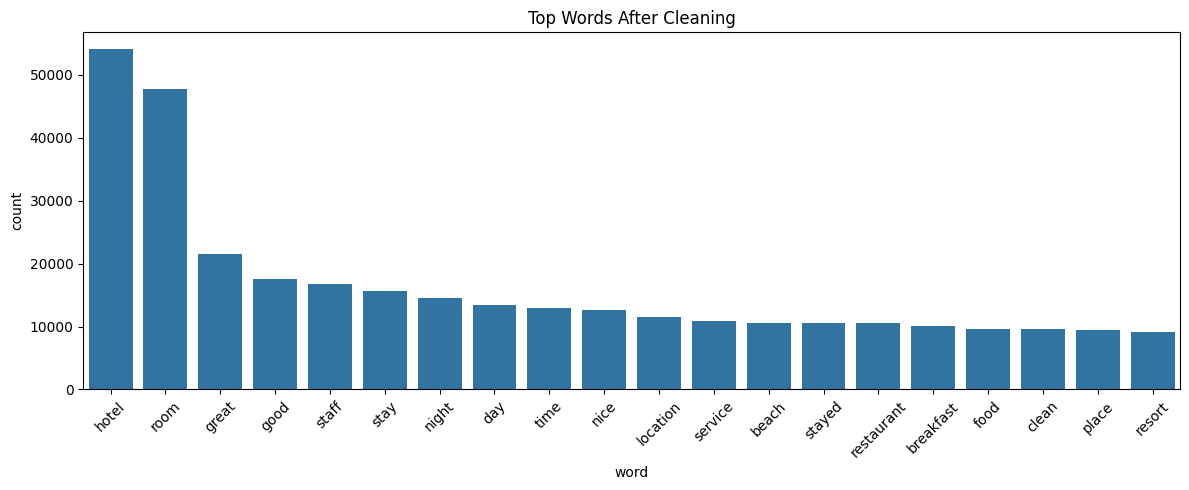

In [11]:
# Show frequent words to visualize cleaned dataset
from collections import Counter  # Counter for frequency stats
freq = Counter(' '.join(df['clean_text'].tolist()).split())  # Build token frequencies
top = pd.DataFrame(freq.most_common(20), columns=['word', 'count'])  # Top 20 words
display(top)  # Display table
plt.figure(figsize=(12, 5))  # Plot canvas
sns.barplot(data=top, x='word', y='count')  # Bar chart
plt.xticks(rotation=45)  # Rotate labels
plt.title('Top Words After Cleaning')  # Title
plt.tight_layout()  # Layout
plt.show()  # Render

In [12]:
# Tokenization + 80/20 split + percentile-based padding
X = df['clean_text'].values  # Text features
y = df['label'].values  # Labels
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)  # 80/20 split
VOCAB_SIZE = 30000  # Max vocab (raised for richer vocabulary coverage)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')  # Create tokenizer
tokenizer.fit_on_texts(X_train_text)  # Fit on train only
X_train_seq = tokenizer.texts_to_sequences(X_train_text)  # Train sequences
X_test_seq = tokenizer.texts_to_sequences(X_test_text)  # Test sequences
lens = np.array([len(s) for s in X_train_seq])  # Sequence lengths
MAX_LEN = int(np.percentile(lens, 95))  # 95th percentile length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')  # Pad train
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')  # Pad test
print('MAX_LEN:', MAX_LEN, 'Train shape:', X_train_pad.shape, 'Test shape:', X_test_pad.shape)  # Shapes

MAX_LEN: 251 Train shape: (16392, 251) Test shape: (4099, 251)


In [13]:
# Build Model 1: Simple RNN + trainable embedding
def build_rnn(vocab_size, max_len, emb_dim=128):  # RNN builder
    m = Sequential(name='simple_rnn')  # Model
    m.add(Embedding(input_dim=vocab_size, output_dim=emb_dim, input_length=max_len))  # Embedding layer
    m.add(SimpleRNN(64))  # Recurrent layer
    m.add(Dropout(0.3))  # Dropout
    m.add(Dense(32, activation='relu'))  # Dense hidden
    m.add(Dense(1, activation='sigmoid'))  # Binary output
    return m  # Return model
model_rnn = build_rnn(VOCAB_SIZE, MAX_LEN)  # Instantiate model
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # Compile model
model_rnn.summary()  # Summary

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Build Model 2: stronger LSTM + trainable embedding
def build_lstm(vocab_size, max_len, emb_dim=200):  # LSTM builder
    m = Sequential()
    m.add(Embedding(input_dim=vocab_size, output_dim=emb_dim, input_length=max_len))  # Embedding layer
    m.add(Bidirectional(LSTM(96, return_sequences=True, dropout=0.25, recurrent_dropout=0.15)))
    m.add(Bidirectional(LSTM(64, dropout=0.25, recurrent_dropout=0.15)))
    m.add(Dropout(0.35))
    m.add(Dense(64, activation='relu'))
    m.add(Dense(1, activation='sigmoid'))
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

model_lstm = build_lstm(VOCAB_SIZE, MAX_LEN)  # Instantiate model
model_lstm.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Build Model 3: LSTM + pretrained embeddings (GloVe vectors via gensim)
import gensim.downloader as api  # Gensim downloader
w2v = api.load('glove-wiki-gigaword-50')  # Load 50d pretrained vectors
EMB_DIM = w2v.vector_size  # Embedding dimension
word_index = tokenizer.word_index  # Tokenizer index
num_words = min(VOCAB_SIZE, len(word_index) + 1)  # Effective vocab size
emb_matrix = np.zeros((num_words, EMB_DIM))  # Init embedding matrix
for w, i in word_index.items():
    if i < num_words and w in w2v:
        emb_matrix[i] = w2v[w]  # Fill vector from pretrained model
def build_lstm_pretrained(max_len, num_words, emb_dim, matrix):  # Model 3 builder
    m = Sequential(name='lstm_pretrained')  # Model
    m.add(Embedding(input_dim=num_words, output_dim=emb_dim, weights=[matrix], input_length=max_len, trainable=False))  # Frozen embedding
    m.add(Bidirectional(LSTM(64)))  # BiLSTM layer
    m.add(Dropout(0.3))  # Dropout
    m.add(Dense(32, activation='relu'))  # Dense hidden
    m.add(Dense(1, activation='sigmoid'))  # Binary output
    return m  # Return model
model_lstm_pre = build_lstm_pretrained(MAX_LEN, num_words, EMB_DIM, emb_matrix)  # Instantiate model
model_lstm_pre.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # Compile model
model_lstm_pre.summary()  # Summary

Model: "lstm_pretrained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,000 (5.72 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,500,000 (5.72 MB)

In [16]:
# Train all models with early stopping
cb = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),  # Prevent overfit
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=2e-6),  # LR reduction
]  # Callback list
def train_one(model, x, y, name, epochs=10, batch_size=64):  # Training helper
    t0 = time.time()  # Start timer
    h = model.fit(x, y, validation_split=0.2, epochs=epochs, batch_size=batch_size, callbacks=cb, verbose=1)  # Fit model
    sec = time.time() - t0  # Elapsed time
    print(name, 'seconds:', round(sec, 2))  # Print timing
    return h, sec  # Return history and time
h_rnn, t_rnn = train_one(model_rnn, X_train_pad, y_train, 'Simple RNN')  # Train model 1
h_lstm, t_lstm = train_one(model_lstm, X_train_pad, y_train, 'LSTM Trainable')  # Train model 2
h_pre, t_pre = train_one(model_lstm_pre, X_train_pad, y_train, 'LSTM Pretrained')  # Train model 3

Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.7356 - loss: 0.5827 - val_accuracy: 0.7341 - val_loss: 0.5793 - learning_rate: 0.0010
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.7407 - loss: 0.5739 - val_accuracy: 0.7341 - val_loss: 0.5784 - learning_rate: 0.0010
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.7530 - loss: 0.5577 - val_accuracy: 0.7286 - val_loss: 0.5875 - learning_rate: 0.0010
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.7484 - loss: 0.5624 - val_accuracy: 0.7335 - val_loss: 0.5799 - learning_rate: 0.0010
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.7491 - loss: 0.5631 - val_accuracy: 0.7322 - val_loss: 0.5811 - learning_rate: 5.0000e-04
Epoch 6/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.7525 - loss: 0.5553 - val_accuracy: 0.7307 - val_loss: 0.5820 - learning_rate: 5.0000e-04
Epoch 7/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.


Simple RNN accuracy: 0.7365
              precision    recall  f1-score   support

           0     0.5000    0.0028    0.0055      1080
           1     0.7369    0.9990    0.8481      3019

    accuracy                         0.7365      4099
   macro avg     0.6184    0.5009    0.4268      4099
weighted avg     0.6745    0.7365    0.6261      4099



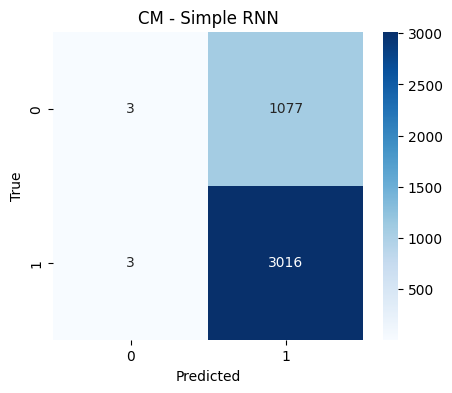


LSTM Trainable accuracy: 0.8827
              precision    recall  f1-score   support

           0     0.8078    0.7278    0.7657      1080
           1     0.9060    0.9381    0.9217      3019

    accuracy                         0.8827      4099
   macro avg     0.8569    0.8329    0.8437      4099
weighted avg     0.8801    0.8827    0.8806      4099



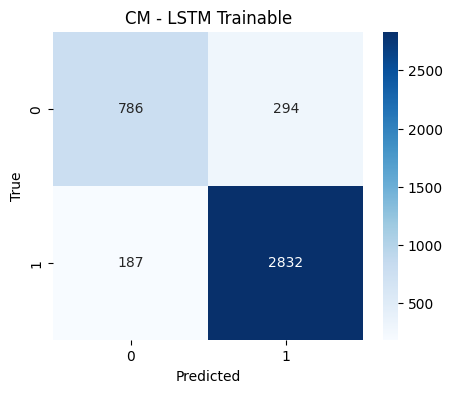


LSTM Pretrained accuracy: 0.8783
              precision    recall  f1-score   support

           0     0.8147    0.6963    0.7509      1080
           1     0.8967    0.9434    0.9195      3019

    accuracy                         0.8783      4099
   macro avg     0.8557    0.8198    0.8352      4099
weighted avg     0.8751    0.8783    0.8750      4099



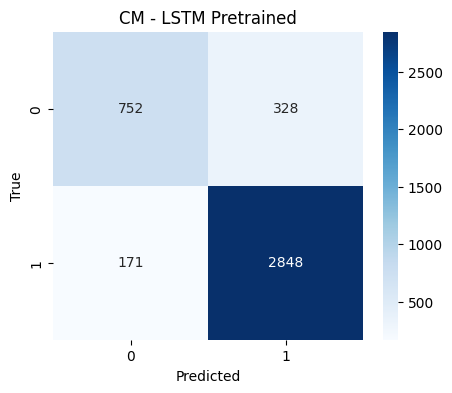

In [17]:
# Evaluate models with accuracy, confusion matrix, and report
def eval_bin(model, x_test, y_test, name):  # Eval helper
    prob = model.predict(x_test, verbose=0).ravel()  # Probabilities
    pred = (prob >= 0.5).astype(int)  # Binary predictions
    acc = accuracy_score(y_test, pred)  # Accuracy
    print('\n' + name + ' accuracy:', round(acc, 4))  # Print accuracy
    print(classification_report(y_test, pred, digits=4))  # Class report
    cm = confusion_matrix(y_test, pred)  # Confusion matrix
    plt.figure(figsize=(5, 4))  # Figure
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # Matrix heatmap
    plt.title('CM - ' + name)  # Title
    plt.xlabel('Predicted')  # X label
    plt.ylabel('True')  # Y label
    plt.show()  # Render
    return acc, pred  # Return accuracy and predictions
acc_rnn, pred_rnn = eval_bin(model_rnn, X_test_pad, y_test, 'Simple RNN')  # Eval model 1
acc_lstm, pred_lstm = eval_bin(model_lstm, X_test_pad, y_test, 'LSTM Trainable')  # Eval model 2
acc_pre, pred_pre = eval_bin(model_lstm_pre, X_test_pad, y_test, 'LSTM Pretrained')  # Eval model 3

In [19]:
summary_rows = [
    {'model': 'Simple RNN', 'accuracy': acc_rnn, 'pred': pred_rnn, 'train_time_sec': t_rnn},
    {'model': 'LSTM Trainable', 'accuracy': acc_lstm, 'pred': pred_lstm, 'train_time_sec': t_lstm},
    {'model': 'LSTM Pretrained', 'accuracy': acc_pre, 'pred': pred_pre, 'train_time_sec': t_pre},
]
for row in summary_rows:
    row['precision'] = precision_score(y_test, row['pred'], zero_division=0)
    row['recall'] = recall_score(y_test, row['pred'], zero_division=0)
    row['f1'] = f1_score(y_test, row['pred'], zero_division=0)
    row['threshold'] = 0.5
    del row['pred']
summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv('part3_metrics_summary.csv', index=False)


,model,accuracy,train_time_sec,precision,recall,f1,threshold
0,Simple RNN,0.736521,74.849362,0.736868,0.999006,0.848144,0.5
1,LSTM Trainable,0.882654,3825.978693,0.905950,0.938059,0.921725,0.5
2,LSTM Pretrained,0.878263,183.845499,0.896725,0.943359,0.919451,0.5


In [1]:
# Optional GUI (extra challenge) with Gradio
import gradio as gr  # Uncomment after installing gradio
def predict_sentiment(text):  # Prediction function
    clean = clean_text(text)  # Apply same cleaning
    seq = tokenizer.texts_to_sequences([clean])  # Tokenize input
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')  # Pad input
    prob = float(model_lstm_pre.predict(pad, verbose=0).ravel()[0])  # Use pretrained model by default
    pred_class = int(prob >= 0.5)  # 1=positive, 0=negative based on training labels
    sentiment = 'Positive' if pred_class == 1 else 'Negative'

    # Debug logs for quick validation during UI testing
    print(f"[DEBUG] raw_input={text!r}")
    print(f"[DEBUG] clean_text={clean!r}")
    print(f"[DEBUG] tokens={len(seq[0])}, nonzero_padded={int((pad[0] != 0).sum())}")
    print(f"[DEBUG] prob_positive_class1={prob:.6f}, threshold=0.5, pred_class={pred_class}, sentiment={sentiment}")

    return {
        'sentiment': sentiment,
        'pred_class': pred_class,
        'prob_positive_class1': prob,
        'threshold': 0.5
    }  # Output label + score + debug-friendly fields
ui = gr.Interface(fn=predict_sentiment, inputs='text', outputs='json', title='Hotel Review Sentiment Predictor')  # Build UI
ui.launch()  # Launch UI



c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
